# A walkthrough of `phyid`: Integrated Information Decomposition (ΦID)

This notebook is a hands-on introduction to `phyid`. It shows the common
workflow — call `calc_PhiID`, read the 16 information atoms, aggregate them
into familiar quantities, and visualize them — on a handful of small systems
whose information structure we know in advance, so the output is interpretable.

**What ΦID does.** Given two time series, ΦID decomposes the time-delayed
mutual information between the system's past `(Xₜ, Yₜ)` and its future
`(Xₜ₊τ, Yₜ₊τ)` into **16 atoms**. Each atom is labelled by a *source role*
(how the information sits in the past) and a *target role* (how it sits in the
future), where each role is one of:

| code | meaning |
|------|---------|
| `r`  | **redundant** — carried by *both* X and Y |
| `x`  | **unique to X** |
| `y`  | **unique to Y** |
| `s`  | **synergistic** — carried only by X and Y *together* |

So `rtr` is redundant→redundant, `sts` is synergistic→synergistic, `xtx` is
unique-X→unique-X (a hallmark of X→X self-transfer), and so on — 4 × 4 = 16.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from phyid.calculate import calc_PhiID, PhiID_atoms_abbr

rng = np.random.default_rng(0)
ROLES = ["r", "x", "y", "s"]  # redundant, unique-X, unique-Y, synergistic
print("The 16 ΦID atoms:", PhiID_atoms_abbr)

The 16 ΦID atoms: ['rtr', 'rtx', 'rty', 'rts', 'xtr', 'xtx', 'xty', 'xts', 'ytr', 'ytx', 'yty', 'yts', 'str', 'stx', 'sty', 'sts']


## The basic call

`calc_PhiID(src, trg, tau, kind='gaussian', redundancy='MMI')` returns
`(atoms, calc)`. `atoms` is a dict mapping each of the 16 atom codes to a
*time-resolved* array (one local value per time step); `calc` holds the
intermediate mutual-information terms. We usually summarize an atom by its
average over time.

In [2]:
def phiid_means(src, trg, tau=1, kind="gaussian", redundancy="MMI"):
    """Run ΦID and return the time-averaged value of each of the 16 atoms."""
    atoms, _ = calc_PhiID(src, trg, tau=tau, kind=kind, redundancy=redundancy)
    return {k: float(np.mean(atoms[k])) for k in PhiID_atoms_abbr}


def lattice_matrix(means):
    """Arrange the 16 atom means into the 4x4 source-role × target-role grid."""
    M = np.zeros((4, 4))
    for i, s in enumerate(ROLES):
        for j, t in enumerate(ROLES):
            M[i, j] = means[f"{s}t{t}"]
    return M


def plot_lattice(means, title, ax=None):
    M = lattice_matrix(means)
    if ax is None:
        _, ax = plt.subplots(figsize=(4.2, 3.6))
    vmax = max(abs(M).max(), 1e-6)
    im = ax.imshow(M, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(4)); ax.set_xticklabels([f"→{r}" for r in ROLES])
    ax.set_yticks(range(4)); ax.set_yticklabels([f"{r}→" for r in ROLES])
    ax.set_xlabel("target role (future)"); ax.set_ylabel("source role (past)")
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=8)
    ax.set_title(title)
    return im

## Example 1 — Redundant channels (shared driver)

Two channels that are noisy copies of a common past signal share their
information. ΦID should put the weight on the **redundant→redundant** atom
`rtr`.

In [3]:
n = 4000
common = np.zeros(n)
for t in range(1, n):
    common[t] = 0.6 * common[t - 1] + rng.normal(0, 1)
src = common + rng.normal(0, 0.2, n)
trg = common + rng.normal(0, 0.2, n)
redundant = phiid_means(src, trg)
print("top atoms:", sorted(redundant.items(), key=lambda kv: -kv[1])[:3])

top atoms: [('rtr', 0.20726656667886795), ('rts', 0.002701152634795723), ('xtr', 0.0026900599197547184)]


## Example 2 — Directed coupling (X drives Y)

Here X's past drives Y's future. The decomposition should expose
**information transfer** as unique-X structure (`xtx` / `xty`), the ΦID
refinement of transfer entropy.

In [4]:
src = rng.normal(0, 1, n)
trg = np.zeros(n)
for t in range(1, n):
    trg[t] = 0.7 * src[t - 1] + 0.3 * rng.normal(0, 1)
transfer = phiid_means(src, trg)
print("top atoms:", sorted(transfer.items(), key=lambda kv: -kv[1])[:3])

top atoms: [('xty', 0.9320447150998804), ('sty', 8.617631939208752e-05), ('sts', 3.5782483037465364e-05)]


## Example 3 — Synergy (XOR dynamics, discrete)

Synergy means the future depends on the *joint* past in a way neither variable
carries alone — the textbook case is XOR. We build a binary system in which
`Yₜ₊₁ = Xₜ XOR Yₜ`, so predicting Y's next bit needs *both* past bits. ΦID
(with `kind='discrete'`) should light up the **synergistic-source** row (`st*`)
— here `sty`, since that synergistic information shapes Y's future
specifically.

In [5]:
x = rng.integers(0, 2, n)
y = np.zeros(n, dtype=int)
for t in range(1, n):
    y[t] = x[t - 1] ^ y[t - 1]
synergy = phiid_means(x.astype(float), y.astype(float), kind="discrete")
print("top atoms:", sorted(synergy.items(), key=lambda kv: -kv[1])[:3])

top atoms: [('sty', 0.9995283955112231), ('rts', 0.00030356803385347855), ('str', 0.0002954826420798907)]


/Users/ludwitt/iit-playground/venv-4.0/lib/python3.12/site-packages/phyid/measures.py:52: RuntimeWarning: divide by zero encountered in log2
  entropy_dict = {comb: -np.log2(p_) for comb, p_ in zip(combs, p)}


## Example 4 — Independent baseline

Two unrelated noise processes: every atom should be ≈ 0.

In [6]:
independent = phiid_means(rng.normal(0, 1, n), rng.normal(0, 1, n))
print("max |atom|:", max(abs(v) for v in independent.values()))

max |atom|: 0.00015520913955912956


## Visualizing the decompositions

The 4×4 lattice makes the structure of each system legible at a glance.

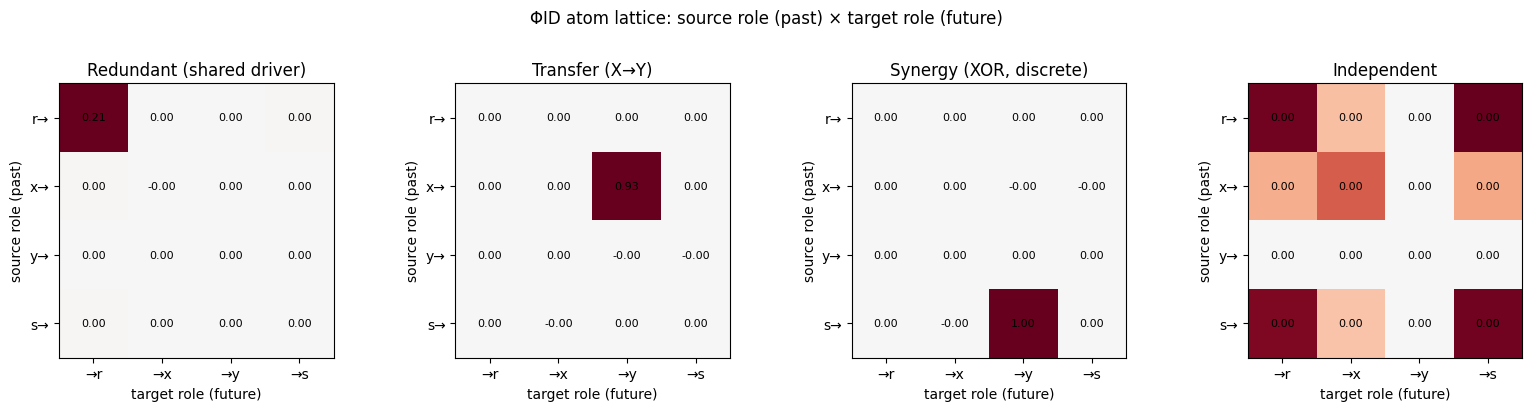

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, (means, title) in zip(
    axes,
    [(redundant, "Redundant (shared driver)"),
     (transfer, "Transfer (X→Y)"),
     (synergy, "Synergy (XOR, discrete)"),
     (independent, "Independent")],
):
    plot_lattice(means, title, ax=ax)
fig.suptitle("ΦID atom lattice: source role (past) × target role (future)", y=1.04)
fig.tight_layout()
plt.show()

## Aggregating atoms into familiar quantities

Standard information measures are sums of ΦID atoms. A few useful aggregates:

- **Total time-delayed mutual information** = sum of all 16 atoms.
- **Storage / self-prediction** ≈ `xtx + yty` (each variable's own past → own
  future).
- **Transfer (X→Y)** picks up unique-X-to-Y structure (`xty`).
- **Synergistic information in the past** is the synergistic-source row
  (`str + stx + sty + sts`) — where it flows (the target role) depends on the
  system.

We compare the four systems on a few of these.

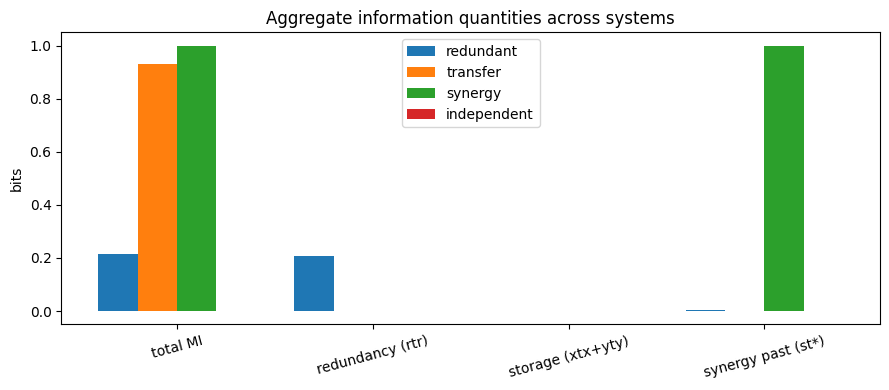

In [8]:
def aggregates(m):
    return {
        "total MI": sum(m.values()),
        "redundancy (rtr)": m["rtr"],
        "storage (xtx+yty)": m["xtx"] + m["yty"],
        "synergy past (st*)": m["str"] + m["stx"] + m["sty"] + m["sts"],
    }

systems = {"redundant": redundant, "transfer": transfer,
           "synergy": synergy, "independent": independent}
agg = {name: aggregates(m) for name, m in systems.items()}

labels = list(next(iter(agg.values())).keys())
xpos = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9, 4))
width = 0.2
for i, (name, vals) in enumerate(agg.items()):
    ax.bar(xpos + i * width, [vals[l] for l in labels], width, label=name)
ax.set_xticks(xpos + 1.5 * width)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel("bits")
ax.set_title("Aggregate information quantities across systems")
ax.legend()
fig.tight_layout()
plt.show()

## Notes

- **`kind`**: use `'gaussian'` for continuous data (assumes a multivariate
  normal model) and `'discrete'` for categorical/binary data.
- **`redundancy`**: `'MMI'` (minimum mutual information) and `'CCS'` (common
  change in surprisal) are two redundancy definitions; the atoms can differ,
  especially for synergy. Try both.
- **`tau`**: the time lag between past and future; pick it to match the
  timescale of the coupling you care about.

### References
- Mediano, Rosas, et al. (2025), *Toward a unified taxonomy of information
  dynamics via Integrated Information Decomposition*, PNAS.
- Luppi et al. (2022), *A synergistic core for human brain evolution and
  cognition*, Nature Neuroscience.